In [36]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from langchain_core.messages import BaseMessage, HumanMessage 
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import os

In [37]:
load_dotenv()

llm = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))

In [38]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [39]:
def generate_joke(state:JokeState) -> JokeState:
    prompt = f"Generate a joke about {state['topic']}"
    response = llm.invoke(prompt).content

    return {'joke': response}



In [40]:
def generate_explanation(state:JokeState) -> JokeState:
    prompt = f"write an explanation for the following joke: {state['joke']}"
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [41]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

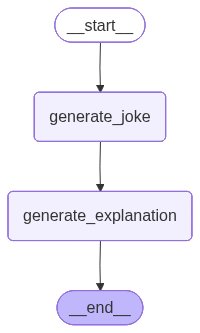

In [42]:
workflow

In [43]:
config1 = {'configurable': {'thread_id': '1'}}
workflow.invoke({'topic': 'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': "Sure! Here's a pizza-themed joke for you:\n\n**Why did the pizza go to the doctor?**\n*Because it was feeling a little... cheesy!* 🍕😄\n\nWant another one? Let me know!",
 'explanation': 'Certainly! Let\'s break down why this pizza-themed joke is funny:\n\n1. **The Setup**:\n   The joke starts with a question: *"Why did the pizza go to the doctor?"* This sets up an expectation that the pizza has a "medical" issue, which is already amusing because pizzas aren’t usually associated with visiting doctors.\n\n2. **The Punchline**:\n   The answer is: *"Because it was feeling a little... cheesy!"* Here’s the clever twist:\n   - **Literal Interpretation**: A pizza going to the doctor because it’s "cheesy" makes no sense—pizzas are inherently cheesy (they’re covered in cheese), and they can’t feel emotions.\n   - **Double Meaning**: "Cheesy" can also mean *corny, overly sentimental, or silly*. So, the pizza is "feeling cheesy" in the sense of being exaggerated or a l

In [47]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Sure! Here's a pizza-themed joke for you:\n\n**Why did the pizza go to the doctor?**\n*Because it was feeling a little... cheesy!* 🍕😄\n\nWant another one? Let me know!", 'explanation': 'Certainly! Let\'s break down why this pizza-themed joke is funny:\n\n1. **The Setup**:\n   The joke starts with a question: *"Why did the pizza go to the doctor?"* This sets up an expectation that the pizza has a "medical" issue, which is already amusing because pizzas aren’t usually associated with visiting doctors.\n\n2. **The Punchline**:\n   The answer is: *"Because it was feeling a little... cheesy!"* Here’s the clever twist:\n   - **Literal Interpretation**: A pizza going to the doctor because it’s "cheesy" makes no sense—pizzas are inherently cheesy (they’re covered in cheese), and they can’t feel emotions.\n   - **Double Meaning**: "Cheesy" can also mean *corny, overly sentimental, or silly*. So, the pizza is "feeling cheesy" in the sense of bein

In [48]:
config2 = {'configurable': {'thread_id': '2'}}
workflow.invoke({'topic': 'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': "Sure! Here's a pasta pun for you:\n\n**Why did the pasta break up with the sauce?**\n*Because it couldn’t handle the committ-ment!*\n\n(But in the end, they found their way back together—*al dente* love always wins!) 🍝😄",
 'explanation': 'This pasta pun is a playful twist on a classic relationship breakup trope, using food metaphors to create a lighthearted joke. Here\'s the breakdown:\n\n1. **The Setup**: The joke poses the question, *"Why did the pasta break up with the sauce?"* This sets up the expectation of a romantic or emotional conflict, much like human relationships.\n\n2. **The Punchline**: The answer plays on the word *"committment"* (as in, the pasta couldn’t handle *commitment*), but it also sounds like *"al dente-ment"* (a pun on the cooking term *al dente*, meaning pasta cooked to be firm yet tender). This clever wordplay ties the "breakup" back to pasta terminology.\n\n3. **The Resolution**: The joke concludes by noting that the pasta and sa

In [49]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': "Sure! Here's a pasta pun for you:\n\n**Why did the pasta break up with the sauce?**\n*Because it couldn’t handle the committ-ment!*\n\n(But in the end, they found their way back together—*al dente* love always wins!) 🍝😄", 'explanation': 'This pasta pun is a playful twist on a classic relationship breakup trope, using food metaphors to create a lighthearted joke. Here\'s the breakdown:\n\n1. **The Setup**: The joke poses the question, *"Why did the pasta break up with the sauce?"* This sets up the expectation of a romantic or emotional conflict, much like human relationships.\n\n2. **The Punchline**: The answer plays on the word *"committment"* (as in, the pasta couldn’t handle *commitment*), but it also sounds like *"al dente-ment"* (a pun on the cooking term *al dente*, meaning pasta cooked to be firm yet tender). This clever wordplay ties the "breakup" back to pasta terminology.\n\n3. **The Resolution**: The joke concludes by noting t

Time Travel

In [54]:
workflow.get_state({'configurable': {'thread_id': '2', 'checkpoint_id': '1f15c029-66bc-6468-8000-2d3204368f1f'}})

StateSnapshot(values={'topic': 'pasta'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f15c029-66bc-6468-8000-2d3204368f1f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-30T08:36:00.853098+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f15c029-66ba-6ad9-bfff-7f77bcd4ed65'}}, tasks=(PregelTask(id='179a10be-28fe-c81f-31df-2fb89cac5185', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': "Sure! Here's a pasta pun for you:\n\n**Why did the pasta break up with the sauce?**\n*Because it couldn’t handle the committ-ment!*\n\n(But in the end, they found their way back together—*al dente* love always wins!) 🍝😄"}),), interrupts=())

In [56]:
workflow.invoke(None,{'configurable': {'thread_id': '2', 'checkpoint_id': '1f15c029-66bc-6468-8000-2d3204368f1f'}})

{'topic': 'pasta',
 'joke': 'Here\'s a pasta pun for you:\n\n**Why did the pasta go to school?**\n*Because it wanted to get a little "al dente-ducation"!*\n\n(Or, if you prefer a shorter one: **What did one noodle say to the other?**\n**"You’re really *carbo*-licious!")**\n\nHope that gives you a *wheel* of laughter! 🍝😄',
 'explanation': 'This joke is a playful example of a **pasta pun**, where words related to pasta are cleverly twisted to sound like other phrases for a humorous effect. Here’s a breakdown of why it’s funny:\n\n### **1. "Al dente-ducation"**\n- **Al dente** is an Italian term meaning "to the tooth," referring to pasta that is cooked but still firm (not mushy).\n- **"Education"** means the process of learning or being taught.\n- By combining them, the joke suggests the pasta went to school to get an *al-dente* (slightly firm) level of education—a clever twist on the phrase.\n\n### **2. "Carbo-licious"**\n- **"Carbo"** is short for carbohydrates, of which pasta is a big 

In [57]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Here\'s a pasta pun for you:\n\n**Why did the pasta go to school?**\n*Because it wanted to get a little "al dente-ducation"!*\n\n(Or, if you prefer a shorter one: **What did one noodle say to the other?**\n**"You’re really *carbo*-licious!")**\n\nHope that gives you a *wheel* of laughter! 🍝😄', 'explanation': 'This joke is a playful example of a **pasta pun**, where words related to pasta are cleverly twisted to sound like other phrases for a humorous effect. Here’s a breakdown of why it’s funny:\n\n### **1. "Al dente-ducation"**\n- **Al dente** is an Italian term meaning "to the tooth," referring to pasta that is cooked but still firm (not mushy).\n- **"Education"** means the process of learning or being taught.\n- By combining them, the joke suggests the pasta went to school to get an *al-dente* (slightly firm) level of education—a clever twist on the phrase.\n\n### **2. "Carbo-licious"**\n- **"Carbo"** is short for carbohydrates, of w

Updating State

In [60]:
workflow.update_state({'configurable': {'thread_id': '2', 'checkpoint_id': '1f15c029-66bc-6468-8000-2d3204368f1f','checkpoint_ns': ""}}, {'topic': 'samosa'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15c063-126d-6d6c-8001-2286b6bf62a1'}}

In [61]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f15c063-126d-6d6c-8001-2286b6bf62a1'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-30T09:01:48.938568+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f15c029-66bc-6468-8000-2d3204368f1f'}}, tasks=(PregelTask(id='74412ee7-5caf-74d6-f7b1-6a6e89994b90', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pasta', 'joke': 'Here\'s a pasta pun for you:\n\n**Why did the pasta go to school?**\n*Because it wanted to get a little "al dente-ducation"!*\n\n(Or, if you prefer a shorter one: **What did one noodle say to the other?**\n**"You’re really *carbo*-licious!")**\n\nHope that gives you a *wheel* of laughter! 🍝😄', 'explanation': 'This joke is a play

In [63]:
workflow.invoke(None,{'configurable': {'thread_id': '2', 'checkpoint_id': '1f15c063-126d-6d6c-8001-2286b6bf62a1'}})

{'topic': 'samosa',
 'joke': 'Sure! Here\'s a samosa-themed joke for you:\n\n**Why did the samosa refuse to fight with the samosa next to it?**\n*Because it didn’t want to get into a* **fry** *and end up at the bottom of a* **chaat** *pile!*\n\n*(Bonus groan-worthy punchline: "They just couldn’t stand the* **crunch** *of competition!")*\n\nHope that gives you a laugh—or at least a good eye-roll! 😄🍟',
 'explanation': 'This samosa-themed joke plays on the exaggerated rivalry between two samosas by using culinary puns to create a humorous scenario. Here’s a breakdown of the wordplay and humor:\n\n1. **"Didn’t want to get into a fry"** – A play on the phrase "get into a fight," but replacing "fight" with "fry" as a reference to how samosas are cooked (fried). This highlights the snack’s preparation while setting up the joke.\n\n2. **"End up at the bottom of a chaat pile"** – *Chaat* is a popular Indian snack that often features crispy fried elements like samosas. The joke imagines the samo

In [64]:
list(workflow.get_state_history(config2))


[StateSnapshot(values={'topic': 'samosa', 'joke': 'Sure! Here\'s a samosa-themed joke for you:\n\n**Why did the samosa refuse to fight with the samosa next to it?**\n*Because it didn’t want to get into a* **fry** *and end up at the bottom of a* **chaat** *pile!*\n\n*(Bonus groan-worthy punchline: "They just couldn’t stand the* **crunch** *of competition!")*\n\nHope that gives you a laugh—or at least a good eye-roll! 😄🍟', 'explanation': 'This samosa-themed joke plays on the exaggerated rivalry between two samosas by using culinary puns to create a humorous scenario. Here’s a breakdown of the wordplay and humor:\n\n1. **"Didn’t want to get into a fry"** – A play on the phrase "get into a fight," but replacing "fight" with "fry" as a reference to how samosas are cooked (fried). This highlights the snack’s preparation while setting up the joke.\n\n2. **"End up at the bottom of a chaat pile"** – *Chaat* is a popular Indian snack that often features crispy fried elements like samosas. The jo